A simple version of a deterministic New Keynesian model in continuous time is given below.

$$\begin{align}
\dot x(t) 
&= -a\Big( (i(t)-\pi(t)) - r^n \Big) - \delta_x\, x(t), 
\qquad a>0, \ \delta_x \ge 0, & (\text{IS})
\\[6pt]
\dot \pi(t) 
&= b\, x(t) - \delta_\pi\big(\pi(t)-\pi^\ast\big),
\qquad b>0, \ \delta_\pi \ge 0, & (\text{PC})
\\[6pt]
i(t) 
&= \bar i + \phi_\pi\big(\pi(t)-\pi^\ast\big) + \phi_x\, x(t),
\qquad \phi_\pi>0,\ \phi_x\ge 0.  & (\text{TR})
\end{align}$$

Here $x$ is the output gap, $\pi$ is inflation, $\pi^\ast $ is equilibrium inflation, $r^n$ is the constant natural interest rate, $i$ is the nominal interest rate and $\bar{i}$ is the equilibrium nominal interest rate, assumed to be given by $\bar{i} = r^n + \pi^\ast$. Equation (IS) is the dynamic IS equation, equation (PC) is the Phillips curve and equation (TR) gives the Taylor rule.

1. Substitute away $i(t)$ using equation (TR), define the deviation of inflation from equilibrium as $p(t):= \pi(t) - \pi^\ast$ and re-write the system in terms of $(x(t),p(t))$ instead of $(x(t),\pi(t))$.
2. Implement the resulting system in SciPy, using the following parameter values:
   $a = 1$, $b = 0.5$, $\delta_x = 0.2$, $\delta_\pi = 0.3$,
   $\phi_\pi = 1.5$, $\phi_x = 0.4$,
   and $r^n = 0.02$, $\pi^\ast = 0.03$.
   Perform the simulations listed below for a horizon $T=20$ using your implementation:
   - Simulate the evolution of the economy starting from initial conditions $x(0)=0.02$ and $p(0)=0.03$ (overheating scenario). Produce the corresponding plots for $x(t)$ and $p(t)$.
   - Simulate the evolution of the economy starting from initial conditions $x(0)=-0.01$ and $p(0)=-0.01$ (recessionary scenario). Produce the corresponding plots for $x(t)$ and $p(t)$.
3. Repeat the simulation for the overheating scenario from point 2 using $\phi_\pi = 0.5$. Produce the corresponding plots for $x(t)$ and $p(t)$.

   $$
   i(t) = \bar{i} + \phi_\pi (\pi(t) - \pi^*) + \phi_x x(t)
   $$

   Where $$( \bar{i} = r^n + \pi^* \). $$

   Substituting \( i(t) \) into the IS equation yields:
   $$
   \dot x(t) = -a \left( \phi_\pi p(t) + \phi_x x(t) + 0.01 \right) - \delta_x x(t)
   $$

3. **Phillips Curve Equation:**
   The existing Phillips curve remains:
   \[
   \dot p(t) = b x(t) - \delta_\pi p(t)
   \]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def model(t, y, a, b, delta_x, delta_pi, phi_pi, phi_x, r_n, pi_star):
    x, p = y
    i = r_n + pi_star + phi_pi * p + phi_x * xv
    dxdt = -a * (phi_pi * p + phi_x * x + (pi_star - r_n)) - delta_x * x
    dpdt = b * x - delta_pi * p
    return [dxdt, dpdt]

# Parameters
a = 1
b = 0.5
delta_x = 0.2
delta_pi = 0.3
phi_pi = 1.5  # First scenario
phi_x = 0.4
r_n = 0.02
pi_star = 0.03
T = 20

# Initial conditions
initial_conditions_overheating = [0.02, 0.03 - pi_star]
initial_conditions_recession = [-0.01, -0.01 - pi_star]

# Time array
t = np.linspace(0, T, 500)

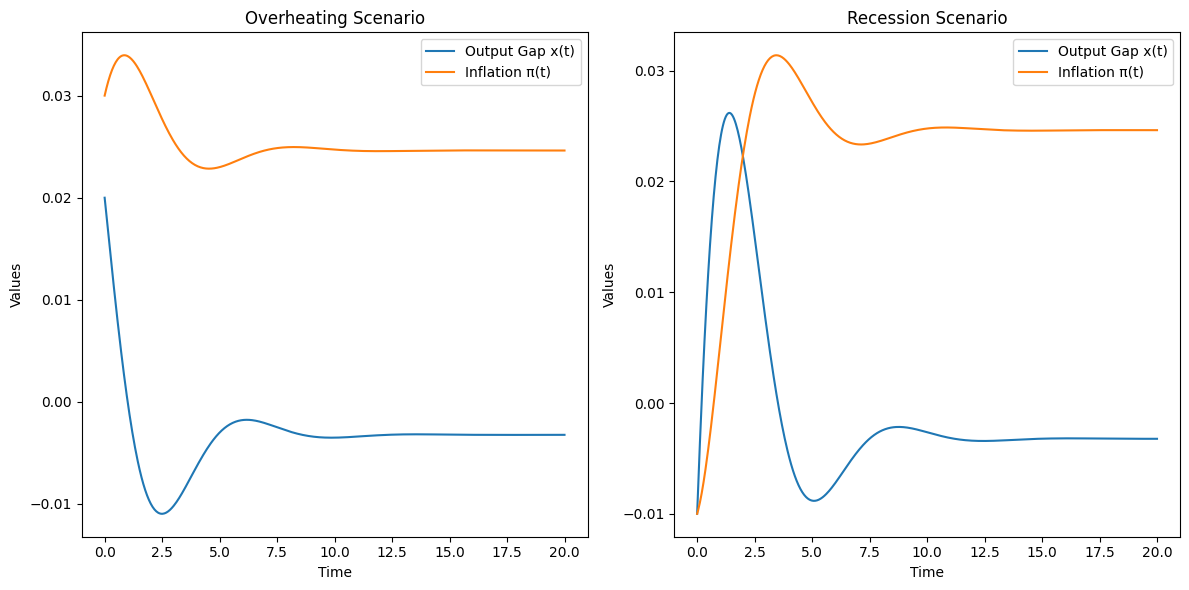

In [3]:
# Simulate overheating scenario
sol_overheating = solve_ivp(model, [0, T], initial_conditions_overheating, 
                             args=(a, b, delta_x, delta_pi, phi_pi, phi_x, r_n, pi_star), 
                             t_eval=t)

# Simulate recession scenario
sol_recession = solve_ivp(model, [0, T], initial_conditions_recession, 
                           args=(a, b, delta_x, delta_pi, phi_pi, phi_x, r_n, pi_star), 
                           t_eval=t)

# Plotting results
plt.figure(figsize=(12, 6))

# Overheating scenario plot
plt.subplot(1, 2, 1)
plt.plot(sol_overheating.t, sol_overheating.y[0], label='Output Gap x(t)')
plt.plot(sol_overheating.t, sol_overheating.y[1] + pi_star, label='Inflation π(t)')
plt.title('Overheating Scenario')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()

# Recession scenario plot
plt.subplot(1, 2, 2)
plt.plot(sol_recession.t, sol_recession.y[0], label='Output Gap x(t)')
plt.plot(sol_recession.t, sol_recession.y[1] + pi_star, label='Inflation π(t)')
plt.title('Recession Scenario')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()

plt.tight_layout()
plt.show()

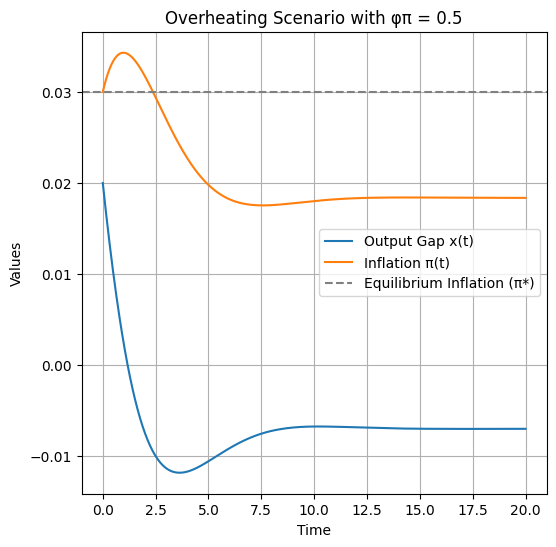

In [7]:
# Update parameter for the new scenario
phi_pi_new = 0.5

# Simulate overheating scenario with new phi_pi
sol_overheating_new = solve_ivp(model, [0, T], initial_conditions_overheating, 
                                 args=(a, b, delta_x, delta_pi, phi_pi_new, phi_x, r_n, pi_star), 
                                 t_eval=t)

# Plotting results for new scenario
plt.figure(figsize=(6, 6))
plt.plot(sol_overheating_new.t, sol_overheating_new.y[0], label='Output Gap x(t)')
plt.plot(sol_overheating_new.t, sol_overheating_new.y[1] + pi_star, label='Inflation π(t)')
plt.title('Overheating Scenario with φπ = 0.5')
plt.xlabel('Time')
plt.ylabel('Values')
plt.axhline(y=pi_star, color='gray', linestyle='--', label='Equilibrium Inflation (π*)')
plt.legend()
plt.grid()
plt.show()